<a href="https://colab.research.google.com/github/Siddharth5723/Daily_learning/blob/main/k_means_clustering_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt


In [9]:
import pandas as pd

high_variance_data = {
    'Name': ['Liam', 'Mia', 'Noah', 'Ava', 'Ethan', 'Sophia', 'Jackson', 'Olivia', 'Lucas', 'Isabella', 'James', 'Charlotte', 'Benjamin', 'Amelia', 'Mason', 'Harper', 'Evelyn', 'Jack', 'Lily', 'Leo'],
    'Age': [18, 19, 21, 20, 22, 38, 45, 40, 42, 35, 68, 72, 65, 75, 70, 25, 62, 30, 55, 28],
    'Income': [12000, 15000, 22000, 18000, 35000, 95000, 145000, 82000, 160000, 60000, 380000, 450000, 290000, 520000, 310000, 250000, 25000, 115000, 210000, 58000]
}

df = pd.DataFrame(high_variance_data)

In [10]:
df.head(20)

,Name,Age,Income
0,Liam,18,12000
1,Mia,19,15000
2,Noah,21,22000
3,Ava,20,18000
4,Ethan,22,35000
5,Sophia,38,95000
6,Jackson,45,145000
7,Olivia,40,82000
8,Lucas,42,160000
9,Isabella,35,60000


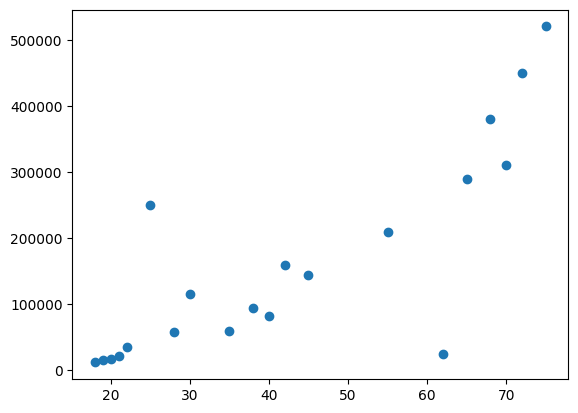

In [11]:
plt.scatter(df['Age'], df['Income'])

In [12]:
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [13]:
y_predicted = km.fit_predict(df[["Age","Income"]])
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 2, 0, 0, 2, 0],
      dtype=int32)

In [14]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income,cluster
0,Liam,18,12000,0
1,Mia,19,15000,0
2,Noah,21,22000,0
3,Ava,20,18000,0
4,Ethan,22,35000,0


/tmp/ipykernel_3673/4133919690.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


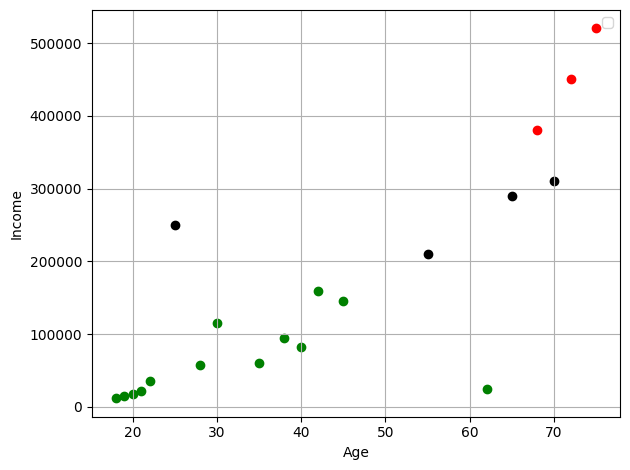

In [17]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]

plt.scatter(df1.Age,df1['Income'],color='green')
plt.scatter(df2.Age,df2['Income'],color='red')
plt.scatter(df3.Age,df3['Income'],color='black')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.tight_layout()
plt.grid(True)

In [23]:
scaler = MinMaxScaler()
scaler.fit(df[['Income']])
df['Income'] = scaler.transform(df[['Income']])
scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])
df


,Name,Age,Income,cluster
0,Liam,0.000000,0.000000,0
1,Mia,0.017544,0.005906,0
2,Noah,0.052632,0.019685,0
3,Ava,0.035088,0.011811,0
4,Ethan,0.070175,0.045276,0
5,Sophia,0.350877,0.163386,0
6,Jackson,0.473684,0.261811,0
7,Olivia,0.385965,0.137795,0
8,Lucas,0.421053,0.291339,0
9,Isabella,0.298246,0.094488,0


In [24]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age' , 'Income']])
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1],
      dtype=int32)

In [25]:
df['cluster'] = y_predicted
df

,Name,Age,Income,cluster
0,Liam,0.000000,0.000000,1
1,Mia,0.017544,0.005906,1
2,Noah,0.052632,0.019685,1
3,Ava,0.035088,0.011811,1
4,Ethan,0.070175,0.045276,1
5,Sophia,0.350877,0.163386,1
6,Jackson,0.473684,0.261811,1
7,Olivia,0.385965,0.137795,1
8,Lucas,0.421053,0.291339,1
9,Isabella,0.298246,0.094488,1


In [27]:
km.cluster_centers_

array([[0.94152047, 0.86220472],
       [0.20107962, 0.1379467 ],
       [0.78947368, 0.38730315]])

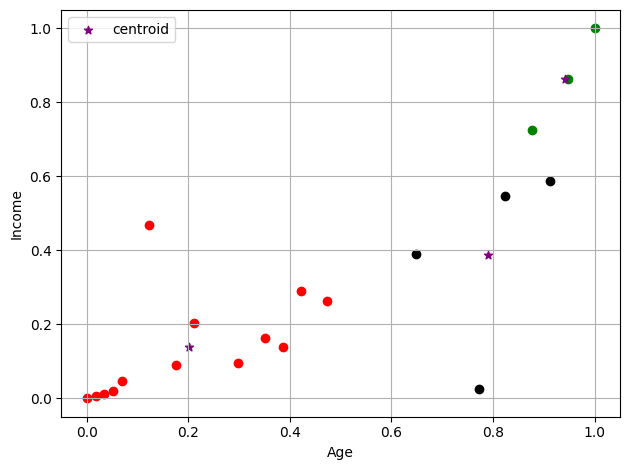

In [28]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]

plt.scatter(df1.Age,df1['Income'],color='green')
plt.scatter(df2.Age,df2['Income'],color='red')
plt.scatter(df3.Age,df3['Income'],color='black')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color="purple",marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.tight_layout()
plt.grid(True)

In [29]:
k_rng = range(1,10)
sse = []
for k in k_rng:
  km = KMeans(n_clusters=k)
  km.fit(df[['Age', 'Income']])
  sse.append(km.inertia_)


In [30]:
sse

[4.149544882546213,
 1.2064302044556248,
 0.6456085845403282,
 0.520980345914045,
 0.3737509431701505,
 0.24428650044844968,
 0.11514538100380188,
 0.10097275563510806,
 0.06858885271197236]

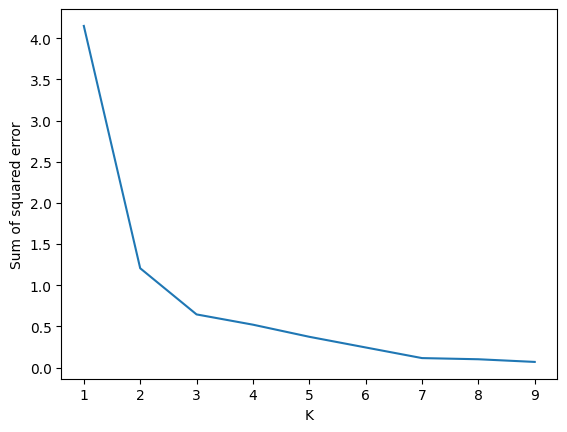

In [31]:
##elbow plot method

plt.xlabel('K')
plt.ylabel("Sum of squared error")
plt.plot(k_rng,sse)